In [1]:
 # BY SAMPRIT CHAKRABORTY 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
   # UNDERSTANDING THE DATASET

In [3]:
#First , I will Understand the dataset 
df = pd.read_csv('retail_store_sales.csv')

In [4]:
df.shape

(12575, 11)

In [5]:
df.head(5)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [6]:
df.dtypes

Transaction ID          str
Customer ID             str
Category                str
Item                    str
Price Per Unit      float64
Quantity            float64
Total Spent         float64
Payment Method          str
Location                str
Transaction Date        str
Discount Applied     object
dtype: object

In [9]:
df.nunique()
#unique values check

Transaction ID      12575
Customer ID            25
Category                8
Item                  200
Price Per Unit         25
Quantity               10
Total Spent           227
Payment Method          3
Location                2
Transaction Date     1114
Discount Applied        2
dtype: int64

In [10]:
df.isnull().sum() 
#Now I will check if there are any missing values or not?

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64

In [11]:
df.isnull().mean() * 100 #Percentage 

Transaction ID       0.000000
Customer ID          0.000000
Category             0.000000
Item                 9.646123
Price Per Unit       4.842942
Quantity             4.803181
Total Spent          4.803181
Payment Method       0.000000
Location             0.000000
Transaction Date     0.000000
Discount Applied    33.391650
dtype: float64

In [12]:
df.duplicated().sum() #TO count duplicate values 

np.int64(0)

In [14]:
df[["Price Per Unit", "Quantity", "Total Spent"]].describe()

,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


In [15]:
#CLEANING DATASET
df = df.dropna(subset=["Item"]) 
#Since Item is a categorical variable with many distinct values.Removing it will be better since it provides incorrect categorical info

In [17]:
#Price per unit is numerical
#so mean or median is aplicable
#We'll use median because prices can have extreme values, and the median is less affected by outliers.
df["Price Per Unit"] = df["Price Per Unit"].fillna(
    df["Price Per Unit"].median()
)
df

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True


In [18]:
#QUANTITY --- MEDIAN
df["Quantity"] = df["Quantity"].fillna(
    df["Quantity"].median()
)
#TOTAL SPENT---MEDIAN
df["Total Spent"] = df["Total Spent"].fillna(
    df["Total Spent"].median()
)
df


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True


In [19]:
#Remove the Discount coloumn
# Since it contains  approximately one-third missing values.
df = df.drop(columns=["Discount Applied"])
df

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02
...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30


In [20]:
#DUPLICATES 
#No. of duplicates before removing
df.duplicated().sum()

np.int64(0)

In [21]:
#Number of duplicates after removing
df = df.drop_duplicates()

In [22]:
print("Rows after removing duplicates:", len(df))

Rows after removing duplicates: 11362


In [23]:
#Why duplicates are a problem :

#Duplicates can cause certain observations to 
#appear more frequently than they really should. This can bias statistical analysis and potentially 
#influence a machine-learning model.

In [27]:
#CATEGORICAL DATA
#Identify 
categorical_cols = df.select_dtypes(include="object").columns
categorical_cols



C:\Users\KIIT\AppData\Local\Temp\ipykernel_35928\1775267560.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


Index(['Transaction ID', 'Customer ID', 'Transaction Date'], dtype='str')

In [28]:
df[categorical_cols].isnull().sum() 
#Missing values in each categorical coloumn


Transaction ID      0
Customer ID         0
Transaction Date    0
dtype: int64

In [30]:
#TYPES OF ENCODING TO DO : 

#Category : One hot 
#Reason : Nominal categories; no natural order

#Item : One hot 
#Reason : Different items have no natural ranking

#Location : One hot 
#Reason : Nominal categories

#Payment : One hot
#Reason: Nominal categories
#We should not treat 
#1. Transaction ID 
#2. Customer ID 
#3. Transaction date 
#as ordinary categorical features. 
#They are identifiers.


In [31]:
#Numerical coloumns : 
numeric_cols = ["Price Per Unit", "Quantity", "Total Spent"]


In [32]:
#Outliers 
#1.IQR METHOD

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, ":", len(outliers), "outliers")

Price Per Unit : 0 outliers
Quantity : 0 outliers
Total Spent : 56 outliers


In [33]:
#2. Z SCORE 
from scipy.stats import zscore

for col in numeric_cols:
    z_scores = np.abs(zscore(df[col]))

    outliers = df[z_scores > 3]

    print(col, ":", len(outliers), "outliers")

Price Per Unit : 0 outliers
Quantity : 0 outliers
Total Spent : 0 outliers


In [34]:
#COMPARISON 
#Outputs of IQR : 
    #Price Per Unit : 0 outliers
    #Quantity : 0 outliers
    #Total Spent : 56 outliers

#Outputs of Z SCORE : 
    #Price Per Unit : 0 outliers
    #Quantity : 0 outliers
    #Total Spent : 0 outliers

In [35]:
#Why might IQR and Z-score identify different numbers of outliers?

#Because IQR looks at the middle 50% of the data
#Anything outside these limits is considered an outlier.
#Z-score measures how far a value is from the mean in terms of standard deviations.
#They differ because Because they respond differently to the shape of the data.



In [36]:

# We should not automatically remove them 
#For example : Total Spent 
#Total Spent is a real spending amount.

#A customer spending considerably more than average doesn't necessarily mean the data is wrong.

#So our decision should be:

#Investigate before making a decision.
#For Example : we can inspect the 56 observations .This is useful because we can check whether those large Total Spent values make sense.

In [37]:
#Feature Scaling : 
numeric_cols = ["Price Per Unit", "Quantity", "Total Spent"]
#NuMERICAL FEATURES

In [38]:
#STANDARD SCALING 
from sklearn.preprocessing import StandardScaler
standard_scaler = StandardScaler()
df_standard = df.copy()

df_standard[numeric_cols] = standard_scaler.fit_transform(
    df_standard[numeric_cols]
)
df_standard[numeric_cols].head()

,Price Per Unit,Quantity,Total Spent
0,-0.452408,1.563891,0.584814
1,0.525651,1.213633,1.387703
2,-0.172962,-1.238171,-0.915320
3,0.385928,1.213633,1.245085
4,-1.011298,0.513117,-0.445207


In [39]:
#Min max scaling :
from sklearn.preprocessing import MinMaxScaler
minmax_scaler = MinMaxScaler()
df_minmax = df.copy()
df_minmax[numeric_cols] = minmax_scaler.fit_transform(
    df_minmax[numeric_cols]
)
df_minmax[numeric_cols].head()


,Price Per Unit,Quantity,Total Spent
0,0.375000,1.000000,0.444444
1,0.666667,0.888889,0.632099
2,0.458333,0.111111,0.093827
3,0.625000,0.888889,0.598765
4,0.208333,0.666667,0.203704


In [41]:
#Comparison

#Standard Scaling : 
#1. Minimum not fixed 
#2. Maximum not fixed
#3. Mean approx 0

#Min Max Scaling 
#1. Minimum = 0
#2. Maximum = 1
#3. Mean not necessarily 0

In [42]:
#What happens to range of features

    #1. standard : Not fixed
    #2. Mim max : 0-1

#What happens to the distribution?

 #   Neither method fundamentally changes the shape of the distribution.

#Which one should we prefer?

#Standard Scaling because ur numerical variables have different units and ranges, and Standard Scaling puts them on a comparable scale with
#mean approx 0
#standard dev : 1(approx)


In [43]:
#VISUALIZATION BEFORE CLEANING 

#reloading df
df_raw = pd.read_csv("retail_store_sales.csv")

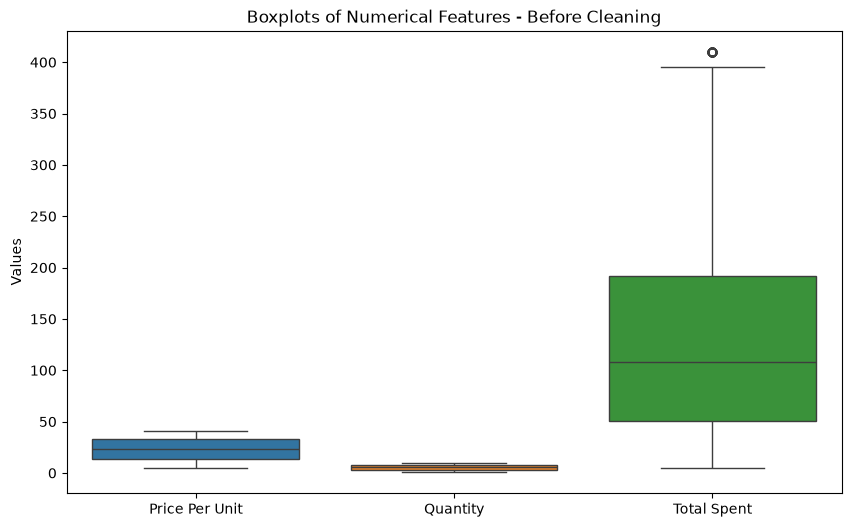

In [44]:
#Box plot
#numerical features 
numeric_cols = ["Price Per Unit", "Quantity", "Total Spent"]

plt.figure(figsize=(10, 6))

sns.boxplot(data=df_raw[numeric_cols])

plt.title("Boxplots of Numerical Features - Before Cleaning")
plt.ylabel("Values")
plt.show()

In [45]:
#Interpretation 
    #the boxplots show that Price Per Unit and Quantity do not contain notable potential outliers according to the IQR criterion.
    #Total Spent shows several observations beyond the upper whisker, indicating potential extreme values.
    #Total Spent also has a relatively wider spread compared with the other numerical features. 
    #The distribution of Total Spent appears somewhat unusual because of the presence of these higher-valued observations.

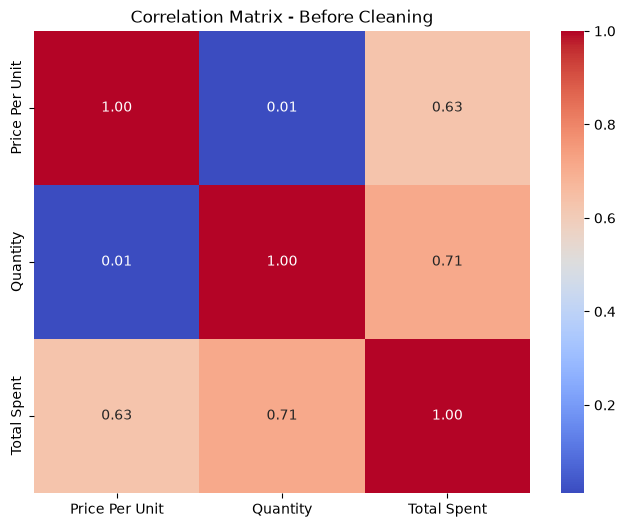

In [46]:
#Correlation Matrix : 
corr_matrix = df_raw[numeric_cols].corr()

corr_matrix
#heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix - Before Cleaning")
plt.show()

In [47]:
#THREE IMPORTANT OBSERVATIONS 
# Observation 1 — Quantity // Total Spent
    #0.712 ... This is a strong positive correlation.
# Observation 2 - Price Per Unit // Total Spent
    #0.631 ... This is also a positive correlation.
#Observation 3- Price Per Unit // Quantity
    #0.012... Extremely close to zero 
    #Therefore, there is almost no linear correlation between the price per unit and the quantity purchased.

In [49]:
#VISUALIZATION AFTER CLEANING 
#Numerical coloumns : 
numeric_cols = ["Price Per Unit", "Quantity", "Total Spent"]

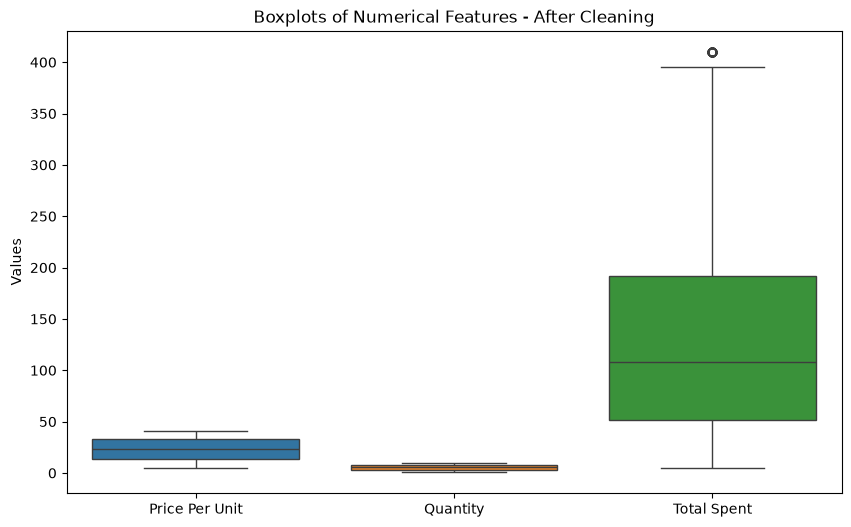

In [50]:
#Box plot After cleaning 
plt.figure(figsize=(10, 6))

sns.boxplot(data=df[numeric_cols])

plt.title("Boxplots of Numerical Features - After Cleaning")
plt.ylabel("Values")
plt.show()

In [51]:
#Which ouliers remain : 
    #Total spent ,because we decided they should be investigated rather than automatically removed.
#Did the spread change : 
    #Distribution may slightly change for Price per Unit , Quantity , Total spent since the numerical values were replaced using median.

#Did preprocessing significantly alter the distribution?
    
    #Most changes came from removing row with missing items 
    #Median imputation of numerical missing values 
    #Since small % of numerical value were missing there wasn't a dramatic change

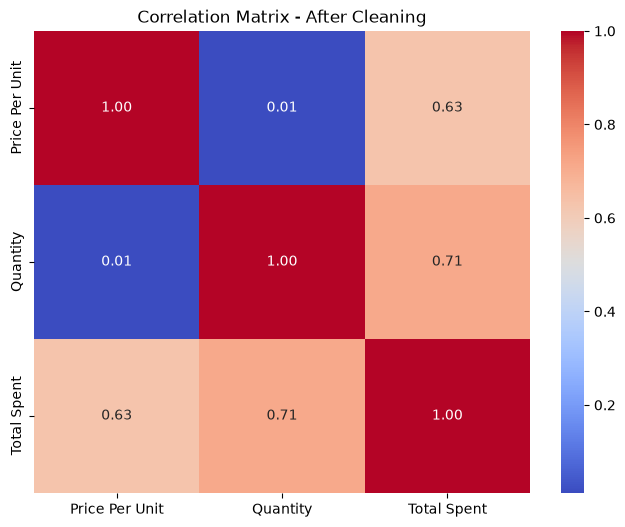

In [52]:
#Correlation Matrix After cleaning : 
corr_clean = df[numeric_cols].corr()

corr_clean
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_clean,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix - After Cleaning")
plt.show()

In [53]:
#1. Did correlations become stronger?
#Yes, slightly.
#The correlation between Quantity and Total Spent increased from 0.712 to 0.713.

#2. Did they become weaker? : No

#3. Did cleaning significantly change relationships? : No

#4. Which relationships remained approximately unchanged?
#two relationships remained almost exactly the same:

#Price Per Unit to Quantity: 0.012 tp 0.012
#Price Per Unit to Total Spent: 0.631 to 0.631


In [54]:
#Zscore before cleaning 
from scipy.stats import zscore

numeric_cols = ["Price Per Unit", "Quantity", "Total Spent"]

for col in numeric_cols:
    data = df_raw[col].dropna()
    z_scores = np.abs(zscore(data))

    outliers = (z_scores > 3).sum()

    print(col, ":", outliers, "outliers")

Price Per Unit : 0 outliers
Quantity : 0 outliers
Total Spent : 0 outliers


In [55]:
#IQR before cleaning 
numeric_cols = ["Price Per Unit", "Quantity", "Total Spent"]

for col in numeric_cols:
    data = df_raw[col].dropna()

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data < lower_bound) | (data > upper_bound)]

    print(col)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of outliers:", len(outliers))
    print()

Price Per Unit
Q1: 14.0
Q3: 33.5
IQR: 19.5
Lower Bound: -15.25
Upper Bound: 62.75
Number of outliers: 0

Quantity
Q1: 3.0
Q3: 8.0
IQR: 5.0
Lower Bound: -4.5
Upper Bound: 15.5
Number of outliers: 0

Total Spent
Q1: 51.0
Q3: 192.0
IQR: 141.0
Lower Bound: -160.5
Upper Bound: 403.5
Number of outliers: 60



In [56]:
#Analysis
comparison_table = pd.DataFrame({
    "Property": [
        "Number of rows",
        "Number of columns",
        "Missing values",
        "Duplicate records",
        "Number of categorical columns",
        "Number of numerical columns",
        "Number of detected outliers (IQR)"
    ],
    "Before Cleaning": [
        df_raw.shape[0],
        df_raw.shape[1],
        df_raw.isnull().sum().sum(),
        df_raw.duplicated().sum(),
        5,
        3,
        60
    ],
    "After Cleaning": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        4,
        3,
        56
    ]
})

comparison_table

,Property,Before Cleaning,After Cleaning
0,Number of rows,12575,11362
1,Number of columns,11,219
2,Missing values,7229,0
3,Duplicate records,0,0
4,Number of categorical columns,5,4
5,Number of numerical columns,3,3
6,Number of detected outliers (IQR),60,56


In [57]:
#1. What was the biggest data-quality problem you discovered?

#The biggest data-quality problem was missing values, particularly in the Discount Applied column. It contained 4,199 missing values, which represented approximately 33.4% of the original dataset. This was substantially higher than the missing values in the other columns.
    
#2. Which preprocessing operation had the greatest impact on the dataset?

#Removing rows with missing Item values had the greatest impact on the number of records. It removed 1,213 rows from the original 12,575 rows.
#Removing the Discount Applied column also had a significant impact because it reduced the number of columns from 11 to 10.
    
#3. Which preprocessing decision was the most difficult to make?

#The most difficult decision was what to do with Discount Applied.
#It had 4,199 missing values, or about one-third of the dataset. Using the mode could have incorrectly assigned thousands of unknown values to either True or False, while keeping the column with so much missing information would reduce its reliability.
#Therefore, removing the column was considered the most appropriate decision.
    
#4. What information could potentially have been lost during cleaning?

#Some information was potentially lost when:
#1,213 rows with missing Item values were removed.
#The Discount Applied column was completely removed.
#Removing the rows means we lost the other information contained in those transactions as well, even though some of their other fields were available.

#5. Is the final dataset genuinely "clean", or merely more suitable for Machine Learning?

#The final dataset is more suitable for Machine Learning rather than perfectly "clean."
#We removed or handled the missing values and duplicates, but the dataset still contains potential outliers in Total Spent. These were retained because they may represent legitimate high-value transactions rather than errors.

In [58]:
df.to_csv("retail_store_sales_cleaned.csv", index=False)

In [60]:
os.listdir()

['.ipynb_checkpoints',
 'assignment.ipynb',
 'Dataanalysis.ipynb',
 'day1.csv',
 'numpy.ipynb',
 'pandas.ipynb',
 'practise.ipynb',
 'Python.ipynb',
 'retail_store_sales.csv',
 'retail_store_sales_cleaned.csv',
 'test.csv',
 'train.csv']

In [ ]:
# MACHINE LEARNING PROBLEM IDENTIFICATION
#Could this dataset potentially be used for a Regression problem?
    #Yes. For regression Total Price can be predicted such as Price per unit , Quantity and Category

# Classification

# Yes , For classification : Payment Method can be predicted using other transaction features like Category item location etc.

#Recommendation :
#I would recommend both Regression and Classification.Regression has a natural numerical target in Total Spent, while the categorical variables provide potential classification targets. However, the features and target would need to be carefully selected before training a real model to avoid data leakage and other problems.


In [ ]:
#Conclusion : 
    #The dataset was successfully inspected, cleaned, analyzed, and prepared for Machine Learning. 
    #Missing values were handled using appropriate methods, duplicate records were checked, categorical data was considered for encoding, and outliers were analyzed using both IQR and Z-score methods. 
    #Standard Scaling and Min-Max Scaling were also applied and compared. The visualizations showed that cleaning did not significantly change the major relationships between numerical variables.
    #Finally, the dataset was found to be potentially suitable for both Regression and Classification, making it more suitable for Machine Learning after preprocessing